In [ ]:
# %pip install -q pandas numpy rank-bm25 python-dotenv requests
# (Optional for embeddings)
# %pip install -q sentence-transformers faiss-cpu

from __future__ import annotations
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv()  # reads ANTHROPIC_API_KEY from .env

random.seed(7); np.random.seed(7)

In [8]:
DATA_DIR = Path("data")

#### Load Data

In [9]:
act_df = pd.read_csv(Path(DATA_DIR, 'activities.csv'))
print(act_df.head(5))

      id           city                            name   theme  \
0  A0001  New York City                    Central Park  sports   
1  A0002  New York City  The Metropolitan Museum of Art  family   
2  A0003  New York City                    Times Square   beach   
3  A0004  New York City               Statue of Liberty   music   
4  A0005  New York City                 Brooklyn Bridge  sports   

   duration_hours  cost_usd opening_hours                  notes  
0             1.0        40   08:00-20:00  Accessible by transit  
1             2.6        30   10:00-17:00      Great photo spots  
2             3.0        40   08:00-19:00             Book ahead  
3             3.1        20   08:00-17:00         Local favorite  
4             1.2        40   08:00-19:00         Local favorite  


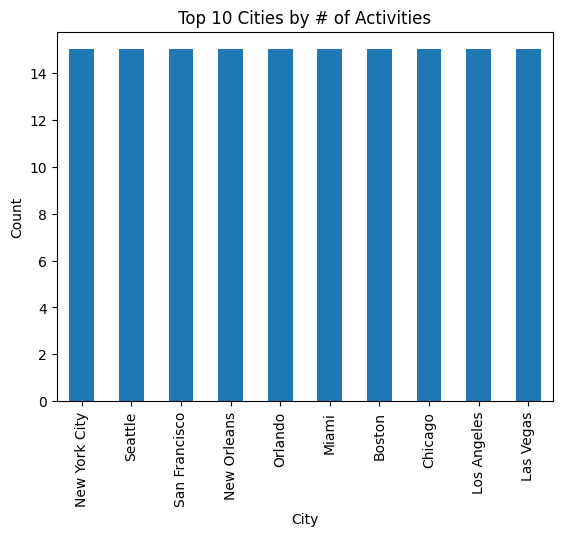

In [10]:
# Activities by city
city_counts = act_df["city"].value_counts().sort_values(ascending=False).head(10)
plt.figure()
city_counts.plot(kind="bar")
plt.title("Top 10 Cities by # of Activities")
plt.xlabel("City"); plt.ylabel("Count")
plt.show()

In [11]:
hotel_df = pd.read_csv(Path(DATA_DIR, 'hotels.csv'))
print(hotel_df.head(5))

      id           city                     name       neighborhood  \
0  H0001  New York City                The Plaza  Historic District   
1  H0002  New York City  The Standard, High Line         Waterfront   
2  H0003  New York City    The Langham, New York      Arts District   
3  H0004  New York City               The Pierre         Waterfront   
4  H0005  New York City         The Bowery Hotel       Near Transit   

   nightly_price_usd  review_score  walk_score             notes  
0                263           4.0          86  Close to transit  
1                146           3.8          86   Great nightlife  
2                123           3.8          77    Good breakfast  
3                285           4.1          69      Near museums  
4                117           4.0          80    Good breakfast  


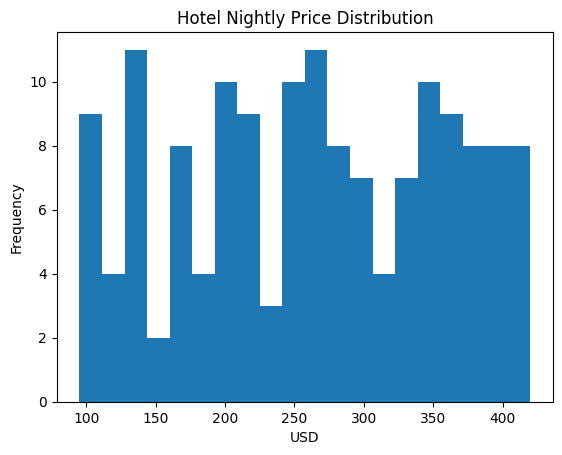

In [12]:
plt.figure()
hotel_df["nightly_price_usd"].plot(kind="hist", bins=20)
plt.title("Hotel Nightly Price Distribution")
plt.xlabel("USD"); plt.ylabel("Frequency")
plt.show()


In [13]:
flight_df = pd.read_csv(Path(DATA_DIR, 'flights.csv'))
print(flight_df.head(5))

      id         origin    destination   airline  price_usd depart_time  \
0  F0001  San Francisco   Philadelphia    Alaska        223       10:45   
1  F0002       Portland  San Francisco    Spirit        601       16:10   
2  F0003         Austin         Denver  American        398       12:30   
3  F0004         Boston  San Francisco    Alaska        162       12:30   
4  F0005         Denver       Portland     Delta        397       18:25   

  arrive_time  on_time_rate  
0       10:43          0.84  
1       12:45          0.78  
2       14:10          0.93  
3       12:45          0.85  
4       08:55          0.80  


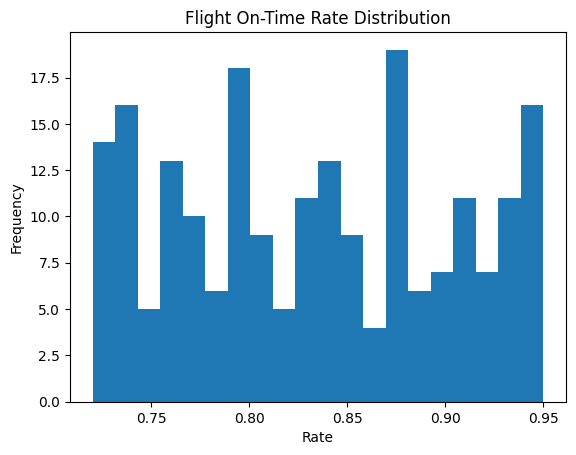

In [14]:
plt.figure()
flight_df["on_time_rate"].plot(kind="hist", bins=20)
plt.title("Flight On-Time Rate Distribution")
plt.xlabel("Rate"); plt.ylabel("Frequency")
plt.show()

#### How to use OpenAI API

In [20]:
import anthropic
client = anthropic.Anthropic()

system_prompt = "Being an expert in trip planning, write clear travel recommendations."
messages = []  # conversation history — grows with each turn

def chat(user_input: str) -> str:
    messages.append({"role": "user", "content": user_input})
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        system=system_prompt,  # top-level only — never inside messages list
        messages=messages      # full history re-sent each call
    )
    reply = response.content[0].text
    messages.append({"role": "assistant", "content": reply})
    return reply

print(chat("I need a 5 day travel plan from San Francisco to Los Angeles."))
print(chat("What about budget options for accommodation?"))  # Claude remembers the prior turn

# 5-Day San Francisco to Los Angeles Road Trip

## Overview
This scenic road trip covers approximately **400 miles** along California's stunning coastline and inland highlights. The recommended route follows **Highway 1 (Pacific Coast Highway)** for maximum scenery.

---

## 🗓️ Day 1 — San Francisco to Santa Cruz (~75 miles)

**Morning**
- Start early in San Francisco
- Walk across the **Golden Gate Bridge** for iconic photos
- Visit **Baker Beach** for stunning bridge views

**Afternoon**
- Drive south along Highway 1
- Stop at **Half Moon Bay** for coastal views and fresh seafood
- Explore the charming downtown area

**Evening**
- Arrive in **Santa Cruz**
- Visit the famous **Santa Cruz Beach Boardwalk**
- **Stay:** Dream Inn or Hotel Paradox

---

## 🗓️ Day 2 — Santa Cruz to Big Sur (~90 miles)

**Morning**
- Grab breakfast at a local café on **Pacific Avenue**
- Visit **Natural Bridges State Beach**

**Afternoon**
- Drive through **Monterey** — explore **Fisherman's Wharf**
- Visit